# ARIMA + Execution Model Backtest for Crypto Relative Value

This notebook implements a **two-layer strategy**:

1. **Signal layer (ARIMA)** on a stationary series: the **log spread**.
2. **Execution layer (classifier)** that decides whether to take the ARIMA signal.

The default example uses **ETH/BTC** because relative pairs are often better suited to ARIMA than outright price prediction.

## What this notebook does

- Downloads OHLCV data with `ccxt`
- Builds the **log spread**
- Runs stationarity diagnostics
- Generates **rolling ARIMA forecasts**
- Engineers features from ARIMA outputs and market state
- Trains an **execution model** (default: Logistic Regression)
- Backtests with costs
- Reports PnL and basic risk metrics

## Notes

- This is a **research notebook**, not production trading code.
- ARIMA is used here as a **structure detector / signal extractor**, not as a standalone edge.
- Execution costs matter a lot. Keep fees and slippage realistic.


In [67]:
!pip install ccxt statsmodels scikit-learn matplotlib pandas numpy

In [68]:
import warnings
warnings.filterwarnings("ignore")

import math
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 100)


In [69]:
# Configuration

CONFIG = {
    # Market data
    "exchange_name": "binance",
    "symbol": "ETH/BTC",
    "timeframe": "4h",
    "limit": 2000,

    # Signal layer
    "arima_order": (2, 0, 2),   # Use d=0 because log spread is often closer to stationary
    "lookback_arima": 250,       # rolling window size used to fit ARIMA
    "forecast_horizon": 1,       # predict next bar
    "zscore_window": 100,
    "vol_window": 24,
    "momentum_window": 12,

    # Label / trade horizon
    "holding_period": 6,         # bars
    "entry_threshold": 0.10,     # minimum absolute ARIMA expected move to consider
    "prob_threshold": 0.55,      # execution model probability threshold

    # Costs
    "fee_bps_per_side": 5.0,     # 5 bps = 0.05% per side
    "slippage_bps_per_side": 2.0,

    # Split / retraining
    "train_frac": 0.70,
    "retrain_every": 50,

    # Execution model
    "use_classifier": True,
    "classifier": "logistic_regression",
}
CONFIG

{'exchange_name': 'binance',
 'symbol': 'ETH/BTC',
 'timeframe': '4h',
 'limit': 2000,
 'arima_order': (2, 0, 2),
 'lookback_arima': 250,
 'forecast_horizon': 1,
 'zscore_window': 100,
 'vol_window': 24,
 'momentum_window': 12,
 'holding_period': 6,
 'entry_threshold': 0.1,
 'prob_threshold': 0.55,
 'fee_bps_per_side': 5.0,
 'slippage_bps_per_side': 2.0,
 'train_frac': 0.7,
 'retrain_every': 50,
 'use_classifier': True,
 'classifier': 'logistic_regression'}

In [70]:
# Data download
CONFIG["exchange_name"] = "kraken" # Colab server can't reach binance
CONFIG["symbol"] = "ETH/BTC"

def get_exchange(name: str):
    import ccxt
    cls = getattr(ccxt, name)
    return cls({"enableRateLimit": True})

def fetch_ohlcv_df(exchange_name: str, symbol: str, timeframe: str, limit: int = 2000) -> pd.DataFrame:
    ex = get_exchange(exchange_name)
    rows = ex.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    df = pd.DataFrame(rows, columns=["timestamp", "open", "high", "low", "close", "volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()
    return df

df = fetch_ohlcv_df(CONFIG["exchange_name"], CONFIG["symbol"], CONFIG["timeframe"], CONFIG["limit"])

df.tail()

,open,high,low,close,volume
timestamp,,,,,
2026-03-19 04:00:00+00:00,0.03105,0.03109,0.03082,0.03088,21.257970
2026-03-19 08:00:00+00:00,0.03086,0.03105,0.03082,0.03100,37.311081
2026-03-19 12:00:00+00:00,0.03098,0.03102,0.03043,0.03054,57.931062
2026-03-19 16:00:00+00:00,0.03053,0.03059,0.03036,0.03049,190.433499
2026-03-19 20:00:00+00:00,0.03048,0.03056,0.03043,0.03051,21.212475


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 721 entries, 2025-11-19 20:00:00+00:00 to 2026-03-19 20:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    721 non-null    float64
 1   high    721 non-null    float64
 2   low     721 non-null    float64
 3   close   721 non-null    float64
 4   volume  721 non-null    float64
dtypes: float64(5)
memory usage: 33.8 KB


In [72]:
df.describe()

,open,high,low,close,volume
count,721.000000,721.000000,721.000000,721.000000,721.000000
mean,0.032108,0.032253,0.031956,0.032106,199.176642
std,0.002214,0.002204,0.002225,0.002214,327.947750
min,0.028430,0.028610,0.028260,0.028460,2.598209
25%,0.029480,0.029670,0.029350,0.029480,45.826567
50%,0.033030,0.033150,0.032870,0.033030,86.342259
75%,0.033960,0.034080,0.033840,0.033970,200.430281
max,0.036470,0.036850,0.036130,0.036460,3444.118676


<Axes: xlabel='timestamp'>

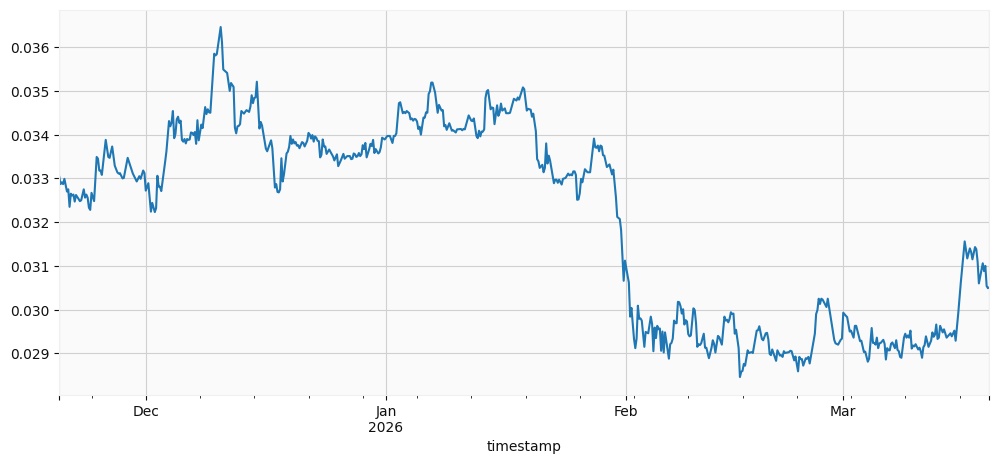

In [73]:
df.close.plot()

In [74]:
!pip install mplfinance

In [75]:
import inspect
import mplfinance as mpf
print("\nAvailable mplfinance styles:", mpf.available_styles())


Available mplfinance styles: ['binance', 'binancedark', 'blueskies', 'brasil', 'charles', 'checkers', 'classic', 'default', 'ibd', 'kenan', 'mike', 'nightclouds', 'sas', 'starsandstripes', 'tradingview', 'yahoo']


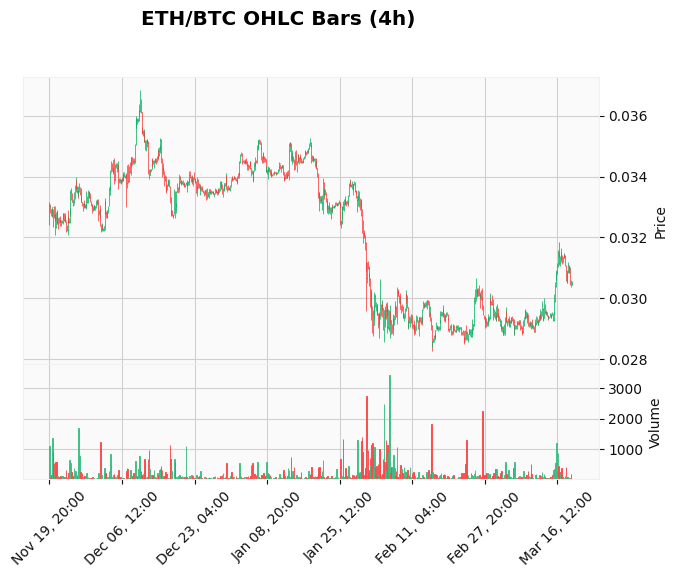

In [76]:
import mplfinance as mpf

plot_df = df[['open', 'high', 'low', 'close', 'volume']].copy()
plot_df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Plotting the OHLC bars
fig, axlist = mpf.plot(plot_df,
                       type='ohlc',
                       style='yahoo',
                       title=f"{CONFIG['symbol']} OHLC Bars ({CONFIG['timeframe']})",
                       ylabel='Price',
                       ylabel_lower='Volume',
                       volume=True,
                       returnfig=True)

plt.show()

## Why this series?

For a quoted relative pair like `ETH/BTC`, the market price already *is* a ratio.  
Using:

\[
\text{log_spread}_t = \log(\text{ETH/BTC close}_t)
\]

is equivalent to modeling the **log ratio**, which is usually better behaved than raw prices for statistical models.


In [77]:
# Build research series

data = df.copy()
data["log_spread"] = np.log(data["close"])
data["ret_1"] = data["log_spread"].diff()
data["rolling_mean"] = data["log_spread"].rolling(CONFIG["zscore_window"]).mean()
data["rolling_std"] = data["log_spread"].rolling(CONFIG["zscore_window"]).std()
data["zscore"] = (data["log_spread"] - data["rolling_mean"]) / data["rolling_std"]
data["volatility"] = data["ret_1"].rolling(CONFIG["vol_window"]).std()
data["momentum"] = data["log_spread"].diff(CONFIG["momentum_window"])
data["vol_zscore"] = (
    (data["volume"] - data["volume"].rolling(CONFIG["zscore_window"]).mean()) /
    data["volume"].rolling(CONFIG["zscore_window"]).std()
)

data[["close", "log_spread", "zscore", "volatility", "momentum", "vol_zscore"]].tail()

,close,log_spread,zscore,volatility,momentum,vol_zscore
timestamp,,,,,,
2026-03-19 04:00:00+00:00,0.03088,-3.477647,1.634290,0.008132,-0.014787,-0.705590
2026-03-19 08:00:00+00:00,0.03100,-3.473768,1.741488,0.008142,-0.012821,-0.616753
2026-03-19 12:00:00+00:00,0.03054,-3.488718,1.141304,0.008632,-0.025220,-0.505877
2026-03-19 16:00:00+00:00,0.03049,-3.490357,1.058713,0.008547,-0.021415,0.179381
2026-03-19 20:00:00+00:00,0.03051,-3.489701,1.063194,0.008191,-0.027479,-0.704112


ADF statistic: -1.1820
p-value:       0.681269
Interpretation: do not reject unit root -> consider differencing, shorter windows, or a different pair.


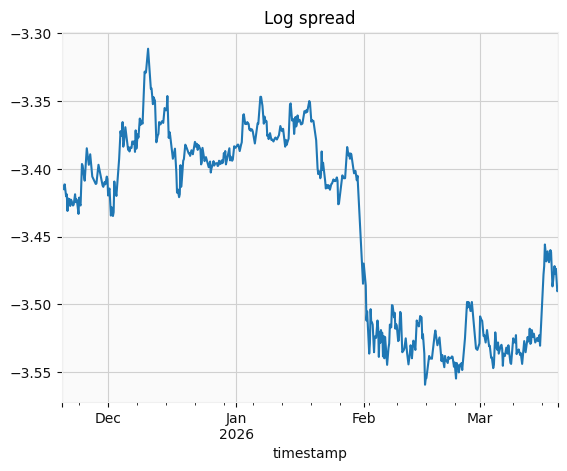

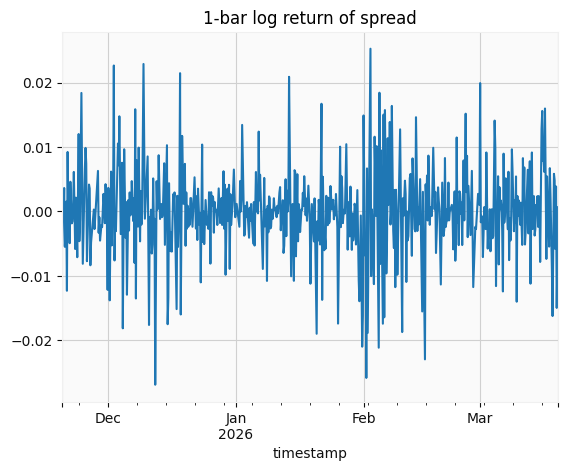

In [78]:
# Stationarity check

series = data["log_spread"].dropna()
adf_stat, pvalue, *_ = adfuller(series)
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value:       {pvalue:.6f}")

if pvalue < 0.05:
    print("Interpretation: reject unit root at 5% -> series looks stationary enough for ARIMA(d=0).")
else:
    print("Interpretation: do not reject unit root -> consider differencing, shorter windows, or a different pair.")

series.plot(title="Log spread")
plt.show()

data["ret_1"].dropna().plot(title="1-bar log return of spread")
plt.show()

## Rolling ARIMA forecast

We fit ARIMA on a **rolling window** to avoid look-ahead bias.  
At each time step:

- fit ARIMA on the last `lookback_arima` bars
- forecast the next bar
- derive:
  - forecasted move
  - residual
  - standardized residual

This is slow but conceptually clean and honest for research.


In [79]:
def rolling_arima_features(
    s: pd.Series,
    order=(2, 0, 2),
    lookback=250,
    forecast_horizon=1,
) -> pd.DataFrame:
    s = s.dropna()
    idx = s.index
    out = pd.DataFrame(index=idx, columns=[
        "arima_forecast",
        "arima_expected_move",
        "arima_residual",
        "arima_resid_std",
        "arima_resid_z",
    ], dtype=float)

    for i in range(lookback, len(s) - forecast_horizon + 1):
        train = s.iloc[i - lookback:i]
        current_idx = s.index[i - 1]
        next_idx = s.index[i]

        try:
            model = ARIMA(train, order=order)
            res = model.fit()
            forecast_val = float(res.forecast(steps=forecast_horizon).iloc[-1])

            current_val = float(s.iloc[i - 1])
            actual_next = float(s.iloc[i])

            resid_hist = pd.Series(res.resid).dropna()
            resid_std = float(resid_hist.std()) if len(resid_hist) > 5 else np.nan
            residual = actual_next - forecast_val
            resid_z = residual / resid_std if resid_std and resid_std > 0 else np.nan

            out.loc[next_idx, "arima_forecast"] = forecast_val
            out.loc[next_idx, "arima_expected_move"] = forecast_val - current_val
            out.loc[next_idx, "arima_residual"] = residual
            out.loc[next_idx, "arima_resid_std"] = resid_std
            out.loc[next_idx, "arima_resid_z"] = resid_z
        except Exception:
            continue

    return out

arima_feats = rolling_arima_features(
    data["log_spread"],
    order=CONFIG["arima_order"],
    lookback=CONFIG["lookback_arima"],
    forecast_horizon=CONFIG["forecast_horizon"],
)
arima_feats.tail()

,arima_forecast,arima_expected_move,arima_residual,arima_resid_std,arima_resid_z
timestamp,,,,,
2026-03-19 04:00:00+00:00,-3.473919,-0.002084,-0.003728,0.006413,-0.581306
2026-03-19 08:00:00+00:00,-3.480483,-0.002836,0.006715,0.006260,1.072621
2026-03-19 12:00:00+00:00,-3.475599,-0.001831,-0.013119,0.006261,-2.095389
2026-03-19 16:00:00+00:00,-3.492370,-0.003652,0.002013,0.006142,0.327784
2026-03-19 20:00:00+00:00,-3.492453,-0.002097,0.002752,0.006155,0.447227


In [80]:
research = data.join(arima_feats)

# Directional signal from ARIMA:
# If ARIMA predicts spread up -> long spread (+1)
# If ARIMA predicts spread down -> short spread (-1)
research["arima_direction"] = np.sign(research["arima_expected_move"])

# Future realized move over holding period
h = CONFIG["holding_period"]
research["future_move_h"] = research["log_spread"].shift(-h) - research["log_spread"]
research["future_abs_move_h"] = research["future_move_h"].abs()

# Binary label for execution model:
# 1 if ARIMA direction was correct over the holding period
research["exec_label"] = (
    (research["arima_direction"] * research["future_move_h"]) > 0
).astype(float)

# Optional label demanding enough move magnitude to matter
research["edge_label"] = (
    ((research["arima_direction"] * research["future_move_h"]) > 0) &
    (research["future_abs_move_h"] > abs(research["arima_expected_move"]).rolling(50).median())
).astype(float)

research[[
    "log_spread", "arima_expected_move", "arima_direction",
    "future_move_h", "exec_label", "edge_label"
]].tail()

,log_spread,arima_expected_move,arima_direction,future_move_h,exec_label,edge_label
timestamp,,,,,,
2026-03-19 04:00:00+00:00,-3.477647,-0.002084,-1.0,NaN,0.0,0.0
2026-03-19 08:00:00+00:00,-3.473768,-0.002836,-1.0,NaN,0.0,0.0
2026-03-19 12:00:00+00:00,-3.488718,-0.001831,-1.0,NaN,0.0,0.0
2026-03-19 16:00:00+00:00,-3.490357,-0.003652,-1.0,NaN,0.0,0.0
2026-03-19 20:00:00+00:00,-3.489701,-0.002097,-1.0,NaN,0.0,0.0


## Feature set for the execution model

The execution model does **not** try to rediscover the market from scratch.  
It uses:

- ARIMA expected move
- absolute ARIMA expected move
- z-score of the spread
- volatility
- momentum
- volume z-score
- ARIMA residual z-score

You can later replace Logistic Regression with:
- XGBoost / LightGBM
- Random Forest
- HMM regime filter + rules
- another classifier/regressor


In [81]:
FEATURES = [
    "arima_expected_move",
    "zscore",
    "volatility",
    "momentum",
    "vol_zscore",
    "arima_resid_z",
]
research["abs_arima_expected_move"] = research["arima_expected_move"].abs()
FEATURES = ["abs_arima_expected_move"] + FEATURES

dataset = research.dropna(subset=FEATURES + ["future_move_h", "exec_label"]).copy()
dataset[FEATURES + ["future_move_h", "exec_label"]].head()

,abs_arima_expected_move,arima_expected_move,zscore,volatility,momentum,vol_zscore,arima_resid_z,future_move_h,exec_label
timestamp,,,,,,,,,
2025-12-31 12:00:00+00:00,0.000049,-0.000049,0.666696,0.004017,0.013351,-0.034953,1.021739,0.001178,0.0
2025-12-31 16:00:00+00:00,0.000407,-0.000407,0.695145,0.004021,0.010670,0.595731,0.017256,-0.000885,1.0
2025-12-31 20:00:00+00:00,0.000663,-0.000663,0.673741,0.003980,0.006513,-0.337721,-0.034242,-0.002363,1.0
2026-01-01 00:00:00+00:00,0.000410,-0.000410,0.914225,0.003977,0.004135,-0.432495,0.244645,0.001178,0.0
2026-01-01 04:00:00+00:00,0.000277,-0.000277,1.106436,0.003950,0.006794,-0.286562,0.225736,0.000000,0.0


In [82]:
# Train/test split

split_idx = int(len(dataset) * CONFIG["train_frac"])
train_df = dataset.iloc[:split_idx].copy()
test_df = dataset.iloc[split_idx:].copy()

print("Train rows:", len(train_df))
print("Test rows: ", len(test_df))
print("Train from:", train_df.index.min(), "to", train_df.index.max())
print("Test  from:", test_df.index.min(), "to", test_df.index.max())

Train rows: 325
Test rows:  140
Train from: 2025-12-31 12:00:00+00:00 to 2026-02-23 12:00:00+00:00
Test  from: 2026-02-23 16:00:00+00:00 to 2026-03-18 20:00:00+00:00


In [83]:
def build_classifier():
    # Simple, stable baseline. Replace with XGBoost later if you want.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ])

clf = build_classifier()
clf.fit(train_df[FEATURES], train_df["exec_label"])

train_probs = clf.predict_proba(train_df[FEATURES])[:, 1]
test_probs = clf.predict_proba(test_df[FEATURES])[:, 1]

print("Train AUC:", round(roc_auc_score(train_df["exec_label"], train_probs), 4))
print("Test  AUC:", round(roc_auc_score(test_df["exec_label"], test_probs), 4))

Train AUC: 0.627
Test  AUC: 0.4983


In [84]:
# Walk-forward backtest with periodic retraining

fee = CONFIG["fee_bps_per_side"] / 10_000.0
slippage = CONFIG["slippage_bps_per_side"] / 10_000.0
round_trip_cost = 2 * (fee + slippage)

all_df = dataset.copy()
test_start = split_idx
retrain_every = CONFIG["retrain_every"]

records = []

wf_clf = None

for i in range(test_start, len(all_df)):
    if (i == test_start) or ((i - test_start) % retrain_every == 0):
        train_slice = all_df.iloc[:i].dropna(subset=FEATURES + ["exec_label"]).copy()
        wf_clf = build_classifier()
        wf_clf.fit(train_slice[FEATURES], train_slice["exec_label"])

    row = all_df.iloc[i]
    direction = np.sign(row["arima_expected_move"])
    abs_signal = abs(row["arima_expected_move"])

    take_trade = False
    prob = np.nan

    if direction != 0 and abs_signal >= CONFIG["entry_threshold"]:
        if CONFIG["use_classifier"]:
            prob = wf_clf.predict_proba(pd.DataFrame([row[FEATURES]], columns=FEATURES))[:, 1][0]
            take_trade = prob >= CONFIG["prob_threshold"]
        else:
            take_trade = True

    gross_return = direction * row["future_move_h"] if take_trade else 0.0
    net_return = gross_return - (round_trip_cost if take_trade else 0.0)

    records.append({
        "timestamp": all_df.index[i],
        "close": row["close"],
        "log_spread": row["log_spread"],
        "direction": direction,
        "abs_signal": abs_signal,
        "prob": prob,
        "take_trade": int(take_trade),
        "future_move_h": row["future_move_h"],
        "gross_return": gross_return,
        "net_return": net_return,
    })

bt = pd.DataFrame(records).set_index("timestamp")
bt.head()

,close,log_spread,direction,abs_signal,prob,take_trade,future_move_h,gross_return,net_return
timestamp,,,,,,,,,
2026-02-23 16:00:00+00:00,0.02887,-3.544952,1.0,0.000806,NaN,0,-0.003470,0.0,0.0
2026-02-23 20:00:00+00:00,0.02872,-3.550162,-1.0,0.000124,NaN,0,0.006940,0.0,0.0
2026-02-24 00:00:00+00:00,0.02881,-3.547033,1.0,0.000831,NaN,0,0.011732,0.0,0.0
2026-02-24 04:00:00+00:00,0.02889,-3.544260,-1.0,0.000334,NaN,0,0.007586,0.0,0.0
2026-02-24 08:00:00+00:00,0.02888,-3.544606,1.0,0.000955,NaN,0,0.019545,0.0,0.0


In [85]:
# Performance metrics

def annualization_factor_from_timeframe(tf: str) -> float:
    tf = tf.lower()
    if tf.endswith("m"):
        minutes = int(tf[:-1])
        return (365 * 24 * 60) / minutes
    if tf.endswith("h"):
        hours = int(tf[:-1])
        return (365 * 24) / hours
    if tf.endswith("d"):
        days = int(tf[:-1])
        return 365 / days
    return 365

def summarize_backtest(bt: pd.DataFrame, timeframe: str):
    rets = bt["net_return"].fillna(0.0)
    trade_rets = bt.loc[bt["take_trade"] == 1, "net_return"].fillna(0.0)

    ann = annualization_factor_from_timeframe(timeframe)
    mean_ret = rets.mean()
    std_ret = rets.std()

    sharpe = (mean_ret / std_ret * math.sqrt(ann)) if std_ret > 0 else np.nan

    downside = rets[rets < 0].std()
    sortino = (mean_ret / downside * math.sqrt(ann)) if downside and downside > 0 else np.nan

    equity = (1 + rets).cumprod()
    cummax = equity.cummax()
    drawdown = equity / cummax - 1
    max_dd = drawdown.min()

    hit_rate = (trade_rets > 0).mean() if len(trade_rets) else np.nan
    avg_trade = trade_rets.mean() if len(trade_rets) else np.nan

    return {
        "bars": len(bt),
        "trades": int(bt["take_trade"].sum()),
        "exposure": bt["take_trade"].mean(),
        "total_return": equity.iloc[-1] - 1 if len(equity) else np.nan,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "hit_rate": hit_rate,
        "avg_trade_return": avg_trade,
    }, equity, drawdown

summary, equity, drawdown = summarize_backtest(bt, CONFIG["timeframe"])
summary

{'bars': 140,
 'trades': 0,
 'exposure': np.float64(0.0),
 'total_return': np.float64(0.0),
 'sharpe': nan,
 'sortino': nan,
 'max_drawdown': 0.0,
 'hit_rate': nan,
 'avg_trade_return': nan}

In [86]:
# Benchmark: ARIMA-only threshold, no execution classifier

base_records = []
for i in range(split_idx, len(dataset)):
    row = dataset.iloc[i]
    direction = np.sign(row["arima_expected_move"])
    abs_signal = abs(row["arima_expected_move"])
    take_trade = int(direction != 0 and abs_signal >= CONFIG["entry_threshold"])
    gross_return = direction * row["future_move_h"] if take_trade else 0.0
    net_return = gross_return - (round_trip_cost if take_trade else 0.0)

    base_records.append({
        "timestamp": dataset.index[i],
        "take_trade": take_trade,
        "net_return": net_return,
    })

bt_base = pd.DataFrame(base_records).set_index("timestamp")
base_summary, base_equity, base_drawdown = summarize_backtest(bt_base, CONFIG["timeframe"])

print("ARIMA + execution model:")
print(summary)
print()
print("ARIMA-only threshold baseline:")
print(base_summary)

ARIMA + execution model:
{'bars': 140, 'trades': 0, 'exposure': np.float64(0.0), 'total_return': np.float64(0.0), 'sharpe': nan, 'sortino': nan, 'max_drawdown': 0.0, 'hit_rate': nan, 'avg_trade_return': nan}

ARIMA-only threshold baseline:
{'bars': 140, 'trades': 0, 'exposure': np.float64(0.0), 'total_return': np.float64(0.0), 'sharpe': nan, 'sortino': nan, 'max_drawdown': 0.0, 'hit_rate': nan, 'avg_trade_return': nan}


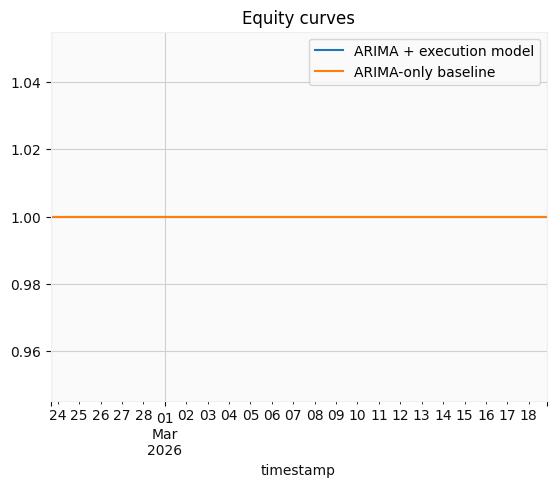

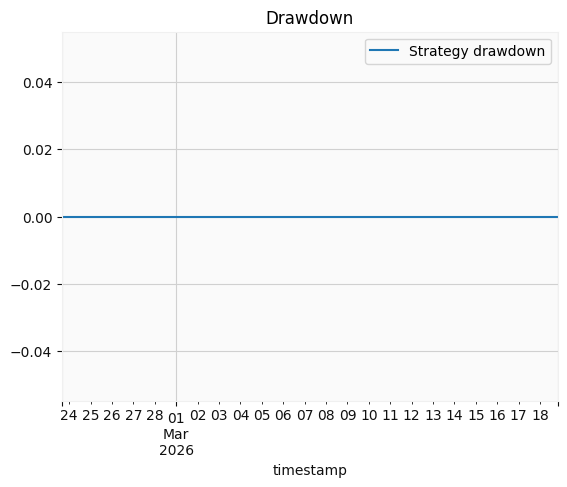

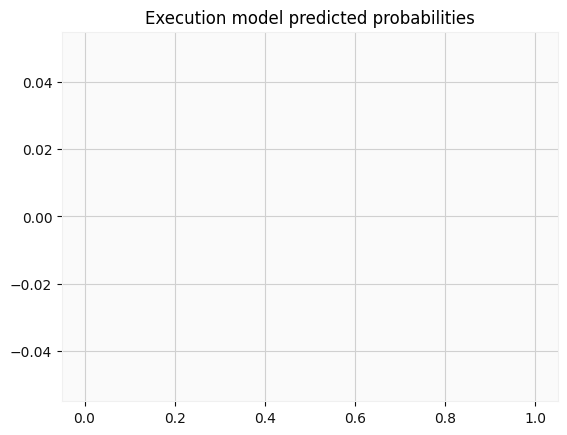

In [87]:
# Plots

fig, ax = plt.subplots()
equity.plot(ax=ax, label="ARIMA + execution model")
base_equity.plot(ax=ax, label="ARIMA-only baseline")
ax.set_title("Equity curves")
ax.legend()
plt.show()

fig, ax = plt.subplots()
drawdown.plot(ax=ax, label="Strategy drawdown")
ax.set_title("Drawdown")
ax.legend()
plt.show()

fig, ax = plt.subplots()
bt["prob"].dropna().hist(ax=ax, bins=30)
ax.set_title("Execution model predicted probabilities")
plt.show()

In [88]:
# Inspect trades

trades = bt[bt["take_trade"] == 1].copy()
trades["cum_pnl"] = trades["net_return"].cumsum()
trades.tail(20)

,close,log_spread,direction,abs_signal,prob,take_trade,future_move_h,gross_return,net_return,cum_pnl
timestamp,,,,,,,,,,


## How to interpret results

A few practical rules:

- If **ARIMA-only** and **ARIMA+execution** both lose after costs, your signal likely has no edge.
- If the classifier improves:
  - hit rate
  - average trade return
  - drawdown
  then it may be filtering weak ARIMA signals correctly.
- If AUC is decent but PnL is bad, your **label or trade mapping** may be wrong.
- If PnL depends on tiny moves smaller than costs, the edge is probably fake.

## What to try next

1. **Try better targets**
   - basis spread
   - funding rate series
   - cointegrated pair spread

2. **Improve features**
   - rolling half-life of mean reversion
   - realized volatility across multiple horizons
   - funding, open interest, basis
   - market regime features

3. **Swap execution model**
   - XGBoost / LightGBM
   - Random Forest
   - regime filter with HMM + simple thresholds

4. **Make labels closer to real execution**
   - triple-barrier labeling
   - risk-adjusted reward labels
   - expected value instead of binary correctness

5. **Use walk-forward hyperparameter search**
   - ARIMA `(p,d,q)`
   - threshold
   - holding period
   - probability threshold

## Important caution

A strategy that looks good in-sample can still fail in live trading due to:
- fees
- spread
- liquidity
- latency
- regime shifts
- overfitting

Treat this as a **research harness**, not a final system.


In [89]:
# Optional: quick parameter sweep example
# This is intentionally simple and slow. Use with care.

def evaluate_config(entry_threshold, prob_threshold, holding_period):
    tmp = dataset.copy()
    tmp["future_move_h"] = tmp["log_spread"].shift(-holding_period) - tmp["log_spread"]
    tmp["exec_label"] = ((np.sign(tmp["arima_expected_move"]) * tmp["future_move_h"]) > 0).astype(float)
    tmp = tmp.dropna(subset=FEATURES + ["future_move_h", "exec_label"]).copy()

    split_idx = int(len(tmp) * CONFIG["train_frac"])
    records = []

    wf_clf = None
    for i in range(split_idx, len(tmp)):
        if (i == split_idx) or ((i - split_idx) % CONFIG["retrain_every"] == 0):
            train_slice = tmp.iloc[:i]
            wf_clf = build_classifier()
            wf_clf.fit(train_slice[FEATURES], train_slice["exec_label"])

        row = tmp.iloc[i]
        direction = np.sign(row["arima_expected_move"])
        abs_signal = abs(row["arima_expected_move"])
        prob = wf_clf.predict_proba(pd.DataFrame([row[FEATURES]], columns=FEATURES))[:, 1][0]
        take_trade = int(direction != 0 and abs_signal >= entry_threshold and prob >= prob_threshold)
        gross_return = direction * row["future_move_h"] if take_trade else 0.0
        net_return = gross_return - (round_trip_cost if take_trade else 0.0)

        records.append({"timestamp": tmp.index[i], "take_trade": take_trade, "net_return": net_return})

    bt_local = pd.DataFrame(records).set_index("timestamp")
    s, _, _ = summarize_backtest(bt_local, CONFIG["timeframe"])
    return s

# Example:
grid_results = []
for e in [0.0002, 0.0004, 0.0006]:
    for p in [0.50, 0.55, 0.60]:
        for h in [3, 6, 12]:
            s = evaluate_config(e, p, h)
            s.update({"entry_threshold": e, "prob_threshold": p, "holding_period": h})
            grid_results.append(s)
pd.DataFrame(grid_results).sort_values("total_return", ascending=False).head(10)


,bars,trades,exposure,total_return,sharpe,sortino,max_drawdown,hit_rate,avg_trade_return,entry_threshold,prob_threshold,holding_period
3,139,14,0.100719,-0.010833,-0.734010,-0.305590,-0.064712,0.428571,-0.000683,0.0002,0.55,3
21,139,14,0.100719,-0.010833,-0.734010,-0.305590,-0.064712,0.428571,-0.000683,0.0006,0.55,3
12,139,14,0.100719,-0.010833,-0.734010,-0.305590,-0.064712,0.428571,-0.000683,0.0004,0.55,3
15,139,12,0.086331,-0.034349,-2.824815,-1.081049,-0.064712,0.333333,-0.002818,0.0004,0.60,3
24,139,12,0.086331,-0.034349,-2.824815,-1.081049,-0.064712,0.333333,-0.002818,0.0006,0.60,3
6,139,12,0.086331,-0.034349,-2.824815,-1.081049,-0.064712,0.333333,-0.002818,0.0002,0.60,3
25,138,16,0.115942,-0.104907,-5.536927,-2.465617,-0.153195,0.375000,-0.006734,0.0006,0.60,6
9,139,28,0.201439,-0.106148,-6.160167,-3.710808,-0.154834,0.392857,-0.003917,0.0004,0.50,3
0,139,28,0.201439,-0.106148,-6.160167,-3.710808,-0.154834,0.392857,-0.003917,0.0002,0.50,3
18,139,28,0.201439,-0.106148,-6.160167,-3.710808,-0.154834,0.392857,-0.003917,0.0006,0.50,3
